In [1]:
import numpy as np

**It generates synthetic (fake) training data for a simple linear regression problem**

In [2]:
np.random.seed(42) # So every time you run this code, you get the exact same "random"
m = 100 # number of training instances (rows in your dataset).
X = 2 * np.random.rand(m, 1) # features
#  generates m(100) random numbers uniformly between 0 and 1.

y = 4 + 2 * X + np.random.randn(m,1) # Creates the target/label vector



In [3]:
X[:5]

array([[0.74908024],
       [1.90142861],
       [1.46398788],
       [1.19731697],
       [0.31203728]])

In [4]:
y[:5]

array([[5.58520754],
       [7.50384988],
       [7.01973654],
       [4.40706502],
       [4.40440267]])

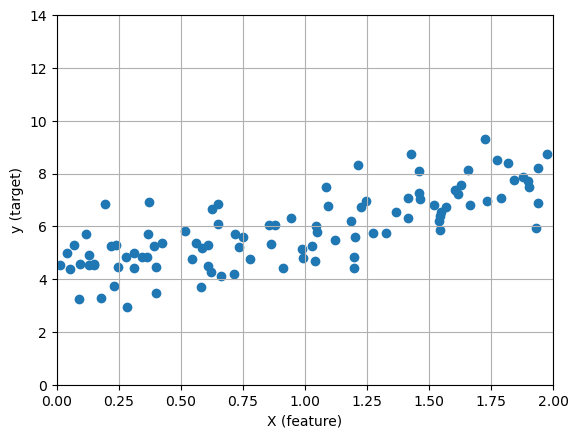

In [5]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.xlabel('X (feature)')
plt.ylabel('y (target)')
plt.xlim(0.0, 2.0)      # X-axis from 0 to 2
plt.ylim(0, 14)         # Y-axis from 0 to 14
plt.grid(True)          
plt.show()

Now let’s compute ˆ𝛉 using the Normal equation. We will use the inv() function
from NumPy’s linear algebra **module (np.linalg)** to compute the **inverse** of a
matrix, and the dot() method for matrix multiplication:

In [6]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) # add x0 =1 to each instance 
# X_b is your original X matrix with an extra column of 1s added to the front.

theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [7]:
X_b[:5]

array([[1.        , 0.74908024],
       [1.        , 1.90142861],
       [1.        , 1.46398788],
       [1.        , 1.19731697],
       [1.        , 0.31203728]])

In [8]:
theta_best

array([[4.21509616],
       [1.77011339]])

* 4.21509616 is your learned **bias (b)**.
* 1.77011339 is your learned **weight (w)**.

In [9]:
X_new = np.array(([0], [2])) # we are only calculating for 2 rows


# X_new represents new, unseen data that you want your trained model to make predictions on.

X_new_b = add_dummy_feature(X_new) # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
# (for example: y_predict =4.215+(2.770×0))
y_predict

array([[4.21509616],
       [7.75532293]])

In [10]:
X_new_b

array([[1., 0.],
       [1., 2.]])


### The Prediction Step (in your $w$ and $b$ notation)
```python
y_predict = X_new_b @ theta_best
```
This is where the actual prediction happens. It takes your new data and multiplies it by your learned parameters. 

Let's look at the math using your preferred notation: **$\hat{y} = b + w \cdot x$**

**Prediction 1 (for $x = 0$):**
$\hat{y} = 4.215 + (2.770 \times 0)$
$\hat{y} = 4.215$  *(This matches the first number in your output!)*

**Prediction 2 (for $x = 2$):**
$\hat{y} = 4.215 + (2.770 \times 2)$
$\hat{y} = 4.215 + 5.540$
$\hat{y} = 9.755$  *(This matches the second number in your output!)*

### Summary
* **`X`** = The data you used to *teach* the model.
* **`X_new`** = The new data you are using to *test* or *use* the model.
* **`y_predict`** = The answers the model guessed for `X_new`.

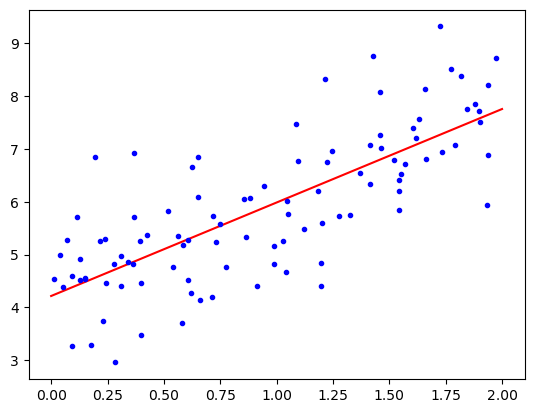

In [11]:
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")
[...]
plt.show()

### Performing linear regression using Scikit-Learn is relatively straightforward:

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_
# bias and weight

(array([4.21509616]), array([[1.77011339]]))

In [14]:
lin_reg.predict(X_new)

array([[4.21509616],
       [7.75532293]])

The Normal Equation requires calculating `(X.T @ X) ** -1` (the matrix inverse). 
But **matrix inverses don't always exist**. They break when:
- You have **more features than samples** (`n > m`)
- Some features are **perfectly redundant** (e.g., you include both `"height_in_cm"` and `"height_in_inches"`)
- Features are highly correlated


**Scikit-Learn doesn't actually use the Normal Equation under the hood, and instead uses a smarter, safer math trick called SVD (Singular Value Decomposition)** 
it
1. Breaks your data matrix $X$ into 3 simpler matrices
2. Safely handles near-zero or redundant columns by ignoring them
3. Reconstructs a **"pseudo-inverse"** ($X^+$) that acts like an inverse but never crashes

**What this means for you:** 
When you call `lin_reg.fit(X, y)`, Scikit-Learn isn't doing `(X.T @ X)^-1`. It's quietly using SVD behind the scenes to safely find the best $w$ and $b$, even if your data is messy or high-dimensional. You don't need to do anything; it's automatic.


**Gradient Descent (GD)** is a generic optimization algorithm capable of finding optimal solutions to a wide range of problems by **iteratively tweaking model parameters** to minimize a cost function.

### 1. The Core Intuition
Imagine you are lost in the mountains in a dense fog and want to reach the bottom of the valley quickly. A good strategy is to feel the slope of the ground and move in the direction of the **steepest descent**. Gradient Descent does exactly this: it measures the local gradient of the error function with regard to the parameter vector $\theta$, and it goes in the direction of the **descending gradient**. Once the gradient is zero, you have reached a minimum.

### 2. How It Works
*   **Random Initialization:** You start by filling $\theta$ with random values.
*   **Baby Steps:** You improve it gradually, taking one step at a time, each attempting to decrease the cost function (e.g., the MSE), until the algorithm **converges to a minimum**.
*   **The Learning Rate:** The size of these steps is determined by the **learning rate** hyperparameter. 
    *   If it is **too small**, the algorithm will require many iterations to converge, taking a long time. 
    *   If it is **too high**, you might jump across the valley and end up on the other side, potentially higher than before, causing the algorithm to **diverge**.

### 3. Technical Challenges and Solutions
*   **Local vs. Global Minima:** A major pitfall is getting stuck in a **local minimum**, which is better than nearby points but not as good as the **global minimum**. You might also get stuck on a flat **plateau**, where progress is extremely slow.
*   **Convexity:** Fortunately, the MSE cost function for a linear regression model is a **convex function**, meaning there are no local minima, only one global minimum. It is also a continuous function with a slope that never changes abruptly, guaranteeing that GD will eventually approach the global minimum if you wait long enough.
*   **Feature Scaling:** GD is sensitive to the scale of features. If features have very different scales, the cost function will look like an elongated bowl, making it take much longer to converge. You should use tools like `StandardScaler` to ensure all features have a similar scale.

### 4. Three Main Variants of Gradient Descent

#### **Batch Gradient Descent**
This version uses the **entire training set** to compute the gradients at every single step. 
*   **Pros:** It scales well with the number of features (better than the Normal Equation).
*   **Cons:** It is **terribly slow** on very large training sets because it must process every instance for every step.

#### **Stochastic Gradient Descent (SGD)**
SGD picks a **single random instance** in the training set at every step and computes the gradients based only on that instance.
*   **Pros:** It is extremely fast and can handle huge datasets that don't fit in memory (**out-of-core learning**). Its randomness can also help it **jump out of local minima**.
*   **Cons:** Its path to the minimum is erratic and never truly settles; it will continue to bounce around even after reaching the vicinity of the minimum. 
*   **Learning Schedule:** To help SGD settle, you can gradually reduce the learning rate over time, a process called **simulated annealing**.

#### **Mini-batch Gradient Descent**
This is a middle ground that computes gradients on **small random sets of instances** called mini-batches.
*   **Pros:** It is less erratic than SGD and can benefit from **hardware acceleration** of matrix operations, especially when using GPUs. It typically walks around a bit closer to the minimum than pure SGD.

### Comparison Summary
| Algorithm | Large $m$ (instances) | Out-of-core | Large $n$ (features) | Scaling Required |
| :--- | :--- | :--- | :--- | :--- |
| **Batch GD** | Slow | No | Fast | Yes |
| **Stochastic GD** | Fast | Yes | Fast | Yes |
| **Mini-batch GD** | Fast | Yes | Fast | Yes |

Let’s look at a quick implementation of this BatchGD:

In [15]:
learning_rate = 0.1
n_epochs = 1000
m = len(X_b) # number of instances

np.random.seed(42)
theta = np.random.randn(2, 1) 

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - learning_rate * gradients

In [16]:
theta

array([[4.21509616],
       [1.77011339]])

This code implements stochastic gradient descent using a simple learning schedule:

In [17]:
n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1) 

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi) # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

In [18]:
theta

array([[4.21052487],
       [1.74877311]])

To perform linear regression using stochastic GD with Scikit-Learn, you can use the
SGDRegressor class, which defaults to optimizing the MSE cost function. The
following code runs for maximum 1,000 epochs (max_iter) or until the loss drops
by less than 10 (tol) during 100 epochs (n_iter_no_change). It starts with a
learning rate of 0.01 (eta0), using the default learning schedule (different from the
one we used). Lastly, it does not use any regularization (penalty=None; more
details on this shortly):

In [19]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",1e-05
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [20]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21154695]), array([1.77379754]))


When you create `sgd_reg = SGDRegressor(...)`, you are setting the "rules of the game" for the algorithm:

* **`max_iter=1000`**: This is the **maximum number of epochs**. The algorithm will loop through your training data at most 1,000 times. 
* **`eta0=0.01`**: This is your **learning rate** (step size). It tells the algorithm how big of a step to take down the cost function bowl during each update.
* **`penalty=None`**: This means **no regularization**. (Regularization is a technique to prevent overfitting by adding a penalty to the cost function. For now, we just want pure, basic SGD).
* **`random_state=42`**: Because SGD picks *random* data points to calculate the gradient, it will give slightly different results every time you run it. Setting this to 42 forces it to use the exact same "randomness" every time, so your code is reproducible.

**The "Early Stopping" Rules (`tol` and `n_iter_no_change`):**
Sometimes, the algorithm finds the best $w$ and $b$ after only 200 loops. Why keep looping 800 more times? 
* **`tol=1e-5`** (Tolerance): This means "0.00001". 
* **`n_iter_no_change=100`**: This means "100 epochs".
* **Combined meaning:** *"If the MSE (error) hasn't improved by at least 0.00001 for 100 consecutive loops, assume we have reached the bottom of the bowl and **stop early**."*



# Polynomial Regression

What if your data is more complex than a straight line? Surprisingly, you can use a
linear model to fit nonlinear data. A simple way to do this is to add powers of each
feature as new features, then train a linear model on this extended set of features.
This technique is called polynomial regression

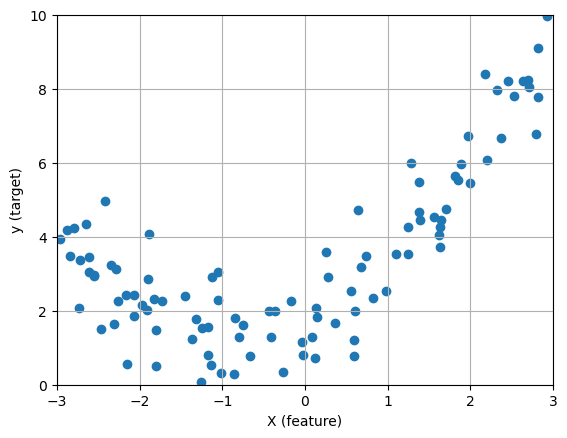

In [21]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)


plt.scatter(X, y)
plt.xlabel('X (feature)')
plt.ylabel('y (target)')
plt.xlim(-3, 3)      
plt.ylim(0, 10)       
plt.grid(True)          
plt.show()

Clearly, a straight line will never fit this data properly. So let’s use Scikit-Learn’s
PolynomialFeatures class to transform our training data, adding the square
(second-degree polynomial) of each feature in the training set as a new feature (in
this case there is just one feature):

In [22]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)


In [23]:
X[0]

array([-0.75275929])

In [24]:
X_poly[0]

array([-0.75275929,  0.56664654])

In [25]:
lin_reg.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

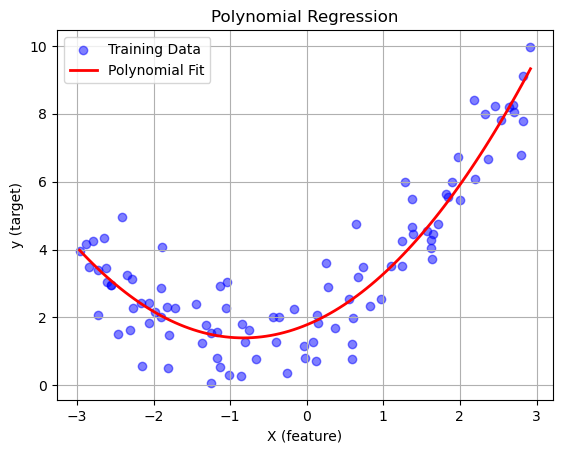

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Plot the original scattered training data
plt.scatter(X, y, color='blue', alpha=0.5, label='Training Data')

# 2. Create a smooth range of X values for the line
# This creates 100 evenly spaced points from the smallest X to the largest X
X_new = np.linspace(X.min(), X.max(), 100).reshape(100, 1)

# 3. Transform these new X values into polynomial features (x and x^2)
X_new_poly = poly_features.transform(X_new)

# 4. Predict the y values for these transformed X values using your trained model
y_poly_pred = lin_reg.predict(X_new_poly)

# 5. Plot the smooth polynomial regression line
plt.plot(X_new, y_poly_pred, color='red', linewidth=2, label='Polynomial Fit')

# 6. Add labels, title, legend, and show the plot
plt.xlabel('X (feature)')
plt.ylabel('y (target)')
plt.title('Polynomial Regression')
plt.legend()
plt.grid(True)
plt.show()

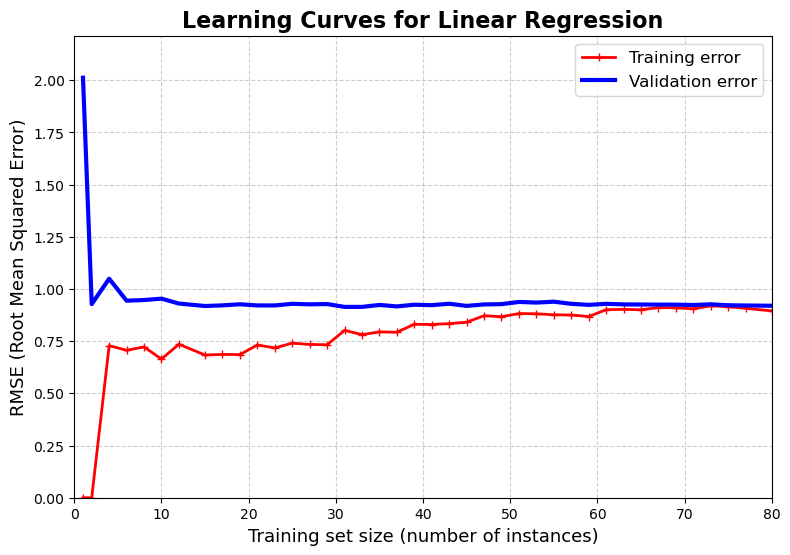

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve

# ==========================================
# 1. Generate the synthetic data (same as before)
# ==========================================
np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

# ==========================================
# 2. Calculate the learning curve
# ==========================================
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, 
    train_sizes=np.linspace(0.01, 1.0, 40), 
    cv=5, 
    scoring="neg_root_mean_squared_error"
)

# Process the scores: average the 5 folds and flip the negative sign back to positive
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

# ==========================================
# 3. Plotting with Beautification
# ==========================================
# Set a nice, wide figure size
plt.figure(figsize=(9, 6))

# Plot the two lines
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="Training error")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="Validation error")

# --- BEAUTIFICATION STARTS HERE ---

# Add a clear title and axis labels with larger fonts
plt.title("Learning Curves for Linear Regression", fontsize=16, fontweight='bold')
plt.xlabel("Training set size (number of instances)", fontsize=13)
plt.ylabel("RMSE (Root Mean Squared Error)", fontsize=13)

# Add a nice, slightly transparent dashed grid
plt.grid(True, linestyle='--', alpha=0.6)

# Place the legend in the best location (upper right is usually good here)
plt.legend(loc="upper right", fontsize=12)

# Make the axes start exactly at 0 so it looks clean
plt.xlim(0, max(train_sizes))
plt.ylim(0, max(max(train_errors), max(valid_errors)) * 1.1) # 10% headroom at the top

# --- BEAUTIFICATION ENDS HERE ---

# Display the plot
plt.show()


### Part 1: The Goldilocks Problem (Underfitting vs. Overfitting)

The text starts by comparing three models on the same data:
1.  **Linear Model (Too Simple / Underfitting):** It just draws a straight line. It misses the curve of the data. It performs poorly on the training data, and it will perform poorly on new data.
2.  **300-Degree Polynomial (Too Complex / Overfitting):** It wiggles crazily to touch every single training point. It memorizes the data (including the random noise). It gets a perfect score on the training data, but it will fail miserably on new, unseen data.
3.  **Quadratic Model (Just Right):** It captures the general U-shape of the data without obsessing over every tiny bump. This is the model that will perform best on new data.

**The Big Question:** In the real world, you don't know the "true" equation that generated the data. So how do you figure out if your model is underfitting or overfitting? 

**The Answer:** You compare its error on the **Training Set** vs. the **Validation Set**.
*   **Underfitting:** High error on Training, High error on Validation. (It's just too dumb to learn the pattern).
*   **Overfitting:** Low error on Training, High error on Validation. (It memorized the training data but failed the exam).

---

### Part 2: What is a "Learning Curve"?

A learning curve is a graph that helps you visually diagnose the problem. 

*   **The X-axis (Bottom):** The amount of training data you are using (e.g., 10% of your data, 20%, 50%, up to 100%).
*   **The Y-axis (Side):** The Error (MSE or RMSE). *Remember: Lower is better.*
*   **The Two Lines:**
    *   **Training Error (Red line):** How badly the model messed up on the data it studied.
    *   **Validation Error (Blue line):** How badly the model messed up on data it *never saw* during training.

#### How to read the shape of the curves:
1.  **When training data is tiny (far left):**
    *   The model can easily memorize 5 data points, so **Training Error is very low**.
    *   But because it only saw 5 points, it knows nothing about the real world, so **Validation Error is super high**.
2.  **As you add more data (moving right):**
    *   It gets harder to memorize everything perfectly, so **Training Error goes UP**.
    *   The model learns the true underlying pattern better, so **Validation Error goes DOWN**.
3.  **When you reach 100% of the data (far right):**
    *   **If the model is Underfitting:** Both lines will flatten out and meet at a **high** error. (Adding more data won't help; the model is too simple).
    *   **If the model is Overfitting:** The Training line will be near zero, but the Validation line will stay high. There will be a **massive gap** between the two lines. (Adding more data will eventually force the lines to close the gap).

---

### Part 3: Breaking Down the Scikit-Learn Code

Now let's translate the code into plain English.

#### 1. Generating the Data
```python
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, 
    train_sizes=np.linspace(0.01, 1.0, 40), 
    cv=5, 
    scoring="neg_root_mean_squared_error"
)
```
Here is what you are telling Scikit-Learn to do:
*   **`LinearRegression()`**: Use a simple straight-line model.
*   **`train_sizes=np.linspace(0.01, 1.0, 40)`**: This is the magic. It tells the function to train the model **40 different times**. First time, use only 1% of the data. Next time, use 3.5%... all the way up to 100%.
*   **`cv=5`**: For *each* of those 40 steps, do 5-fold cross-validation (train/validate 5 times and average the result) to ensure the error metric is stable.
*   **`scoring="neg_root_mean_squared_error"`**: *Wait, why "neg" (negative)?* Scikit-Learn's internal logic assumes that **higher numbers are always better** (like Accuracy). But Error is the opposite: **lower is better**. To trick Scikit-Learn, it makes the error negative (e.g., an error of 5 becomes -5. An error of 10 becomes -10. Now -5 is "higher" than -10, so Scikit-Learn is happy).

#### 2. Fixing the Negative Signs
```python
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
```
Because we humans prefer positive numbers for errors, we just multiply everything by `-1` to flip the signs back to normal. 
*   `.mean(axis=1)` just averages the 5 cross-validation folds for each step.
*   Now we have clean, positive lists of Training Errors and Validation Errors.

#### 3. Plotting the Curves
```python
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
# ... (code to add labels, grid, etc.)
plt.show()
```
This is just standard Matplotlib code. 
*   It plots the 40 data sizes on the X-axis.
*   It plots the Training Errors as a **red line with plus signs**.
*   It plots the Validation Errors as a **thick blue line**.

### Summary
You just wrote code that automatically trains a model on increasingly larger chunks of your data, measures how well it does on both the training data and unseen validation data, and plots the results. 

By looking at the final plot, you can instantly tell if you need to **add more data**, **make the model more complex**, or **simplify the model**.

### Ridge Regression

In [29]:
from sklearn.linear_model import Ridge

In [30]:
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])


array([8.36585531])

In [31]:
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None, max_iter=1000, eta0=0.01, random_state=42)

In [38]:
sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l1'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",None
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [33]:
sgd_reg.predict([[1.5]])

array([8.36750446])

### Lasso Regression

In [34]:
from sklearn.linear_model import Lasso


In [35]:
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([8.2105793])

In [36]:
sgd_reg = SGDRegressor(penalty="l1", alpha=0.1 / m, tol=None, max_iter=1000, eta0=0.01, random_state=42)

In [39]:
sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l1'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",None
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [40]:
sgd_reg.predict([[1.5]])

array([8.37031859])

### Elastic Net Regression

In [41]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([8.10683147])

### Early Stopping

In [51]:
from copy import deepcopy
import numpy as np
from sklearn.metrics import root_mean_squared_error 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split

In [52]:

# FIX : Use .ravel() to flatten y into a 1D array to stop the warning
X_train, X_valid, y_train, y_valid = train_test_split(X, y.ravel(), test_size=0.2, random_state=42)

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)

sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
best_model = None # Good practice to initialize this

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    
    # FIX 1 (Applied): Use the new function instead of mean_squared_error(..., squared=False)
    val_error = root_mean_squared_error (y_valid, y_valid_predict)
    
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

print(f"Training finished! Best Validation RMSE: {best_valid_rmse:.4f}")

Training finished! Best Validation RMSE: 0.8315



### 1. Ridge Regression
**Ridge regression** (also known as **Tikhonov regularization**) adds a regularization term equal to $\alpha \sum_{i=1}^{n} \theta_i^2$ to the Mean Squared Error (MSE) cost function during training. 
*   **Purpose:** This forces the learning algorithm to fit the data while keeping the model weights as small as possible, making the model less flexible and reducing the risk of overfitting.
*   **The $\alpha$ Hyperparameter:** The value of $\alpha$ controls the regularization strength. If $\alpha = 0$, the model is simply standard linear regression; if $\alpha$ is very large, the weights end up close to zero, resulting in a flat line through the data's mean.
*   **Scaling Requirement:** Ridge regression is sensitive to the scale of input features, so it is important to **scale the data** (e.g., using `StandardScaler`) before training.
*   **Solution Methods:** It can be solved either through a **closed-form equation** or by using **gradient descent**.

### 2. Lasso Regression
**Lasso regression** (Least Absolute Shrinkage and Selection Operator) adds a regularization term to the cost function using the **$\ell_1$ norm** of the weight vector ($\sum_{i=1}^{n} |\theta_i|$).
*   **Automatic Feature Selection:** A key characteristic of Lasso is that it tends to eliminate the weights of the least important features by setting them exactly to **zero**.
*   **Sparse Models:** Because it zeros out unimportant weights, Lasso automatically performs feature selection and outputs a **sparse model** with few nonzero weights.
*   **Trade-off:** If $\alpha$ is too high, the model becomes too sparse and performance may plummet.

### 3. Elastic Net Regression
**Elastic Net** is a middle ground that combines the regularization terms of both Ridge and Lasso.
*   **Mix Ratio ($r$):** The regularization term is a weighted sum of the Ridge and Lasso penalties, controlled by a mix ratio $r$. When $r=0$, it is equivalent to Ridge; when $r=1$, it is equivalent to Lasso.
*   **Preferred Use Case:** Elastic Net is generally preferred over Lasso because Lasso can behave erratically when the number of features exceeds the number of training instances or when features are strongly correlated.

### Which One Should You Use?
According to the sources, it is almost always preferable to have at least a little bit of regularization, so **plain linear regression should generally be avoided**. 
*   **Ridge** is a good default choice.
*   **Lasso or Elastic Net** are better if you suspect that only a few features are actually useful.
*   **Elastic Net** is generally preferred over Lasso in complex feature scenarios.

### Early Stopping
**Early stopping** is a very different way to regularize iterative learning algorithms like Gradient Descent.
*   **Method:** You evaluate the model's performance on a validation set at the end of every epoch and **stop training as soon as the validation error reaches a minimum**. 
*   **Benefit:** This prevents the model from continuing to learn the noise in the training data as the error on the training set continues to drop while the validation error begins to rise.
*   **"Free Lunch":** Geoffrey Hinton referred to this as a "beautiful free lunch" because it is a highly efficient and simple regularization technique.

### 1. The Naming: L1 vs. L2
In mathematics, "L1" and "L2" refer to how we measure the "size" or "length" of a vector (in this case, the vector of your weights).

*   **L2 Norm (Ridge Regression):** Calculates the size of the weights by **squaring** them ($w^2$). 
*   **L1 Norm (Lasso Regression):** Calculates the size of the weights by taking their **absolute value** ($|w|$).

You said: *"Ridge just makes the weight smaller... and Lasso makes unimportant [weights] to zero."* 
